**Task 1** — Data Loading & Exploration

 - Load the CSV file using Pandas

In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("Housing.csv")

- Display the first 10 rows

In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


- Check how many rows and columns are there

In [6]:
print("Rows and Columns:", df.shape)

Rows and Columns: (545, 13)


In [7]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


 - Check for missing values in each column

In [8]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


 - Identify which column is the target (Price) and which are features

In [9]:
target = "price"
features = df.drop("price", axis=1).columns

print("Target Column:", target)
print("Feature Columns:")
print(features)

Target Column: price
Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


**Task 2** — Data Cleaning

- Handle missing values

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


- Remove duplicate rows, if any

In [12]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (545, 13)


In [13]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


- Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding

In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [15]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


 - Keep only the columns that are meaningful for predicting price

In [16]:
print(df_encoded.dtypes)

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                        bool
guestroom_yes                       bool
basement_yes                        bool
hotwaterheating_yes                 bool
airconditioning_yes                 bool
prefarea_yes                        bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [17]:
print("Final Dataset Shape:", df_encoded.shape)

Final Dataset Shape: (545, 14)


**Task 3** — Model Building

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [19]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (545, 13)
y Shape: (545,)


- Split the data into training and test sets

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 13)
Testing Data: (109, 13)


- Train a Linear Regression model to predict house price

In [21]:
lr = LinearRegression()

lr.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [22]:
lr_pred = lr.predict(X_test)

print(lr_pred[:5])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955]


 - Evaluate it using MAE, RMSE, and R² Score

In [23]:
mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Results
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


 - Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression model

In [24]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [26]:
rf_pred = rf.predict(X_test)

print(rf_pred[:5])

[5377680.   7287070.   3747528.75 4502120.   3748885.  ]


In [27]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [28]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2 Score": [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


**Task 4** — Visualization (Minimum 3 charts)

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional styling
sns.set_style("whitegrid")

In [30]:
import os

if not os.path.exists("charts"):
    os.makedirs("charts")

print("Charts folder created successfully!")

Charts folder created successfully!


**Chart 1**: Histogram showing the distribution of house prices

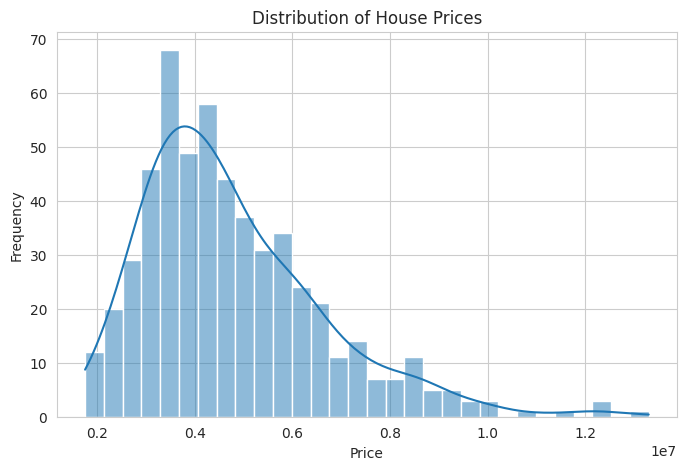

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/price_distribution.png")

plt.show()

 **Chart 2**: Correlation heatmap showing which features relate most strongly to price

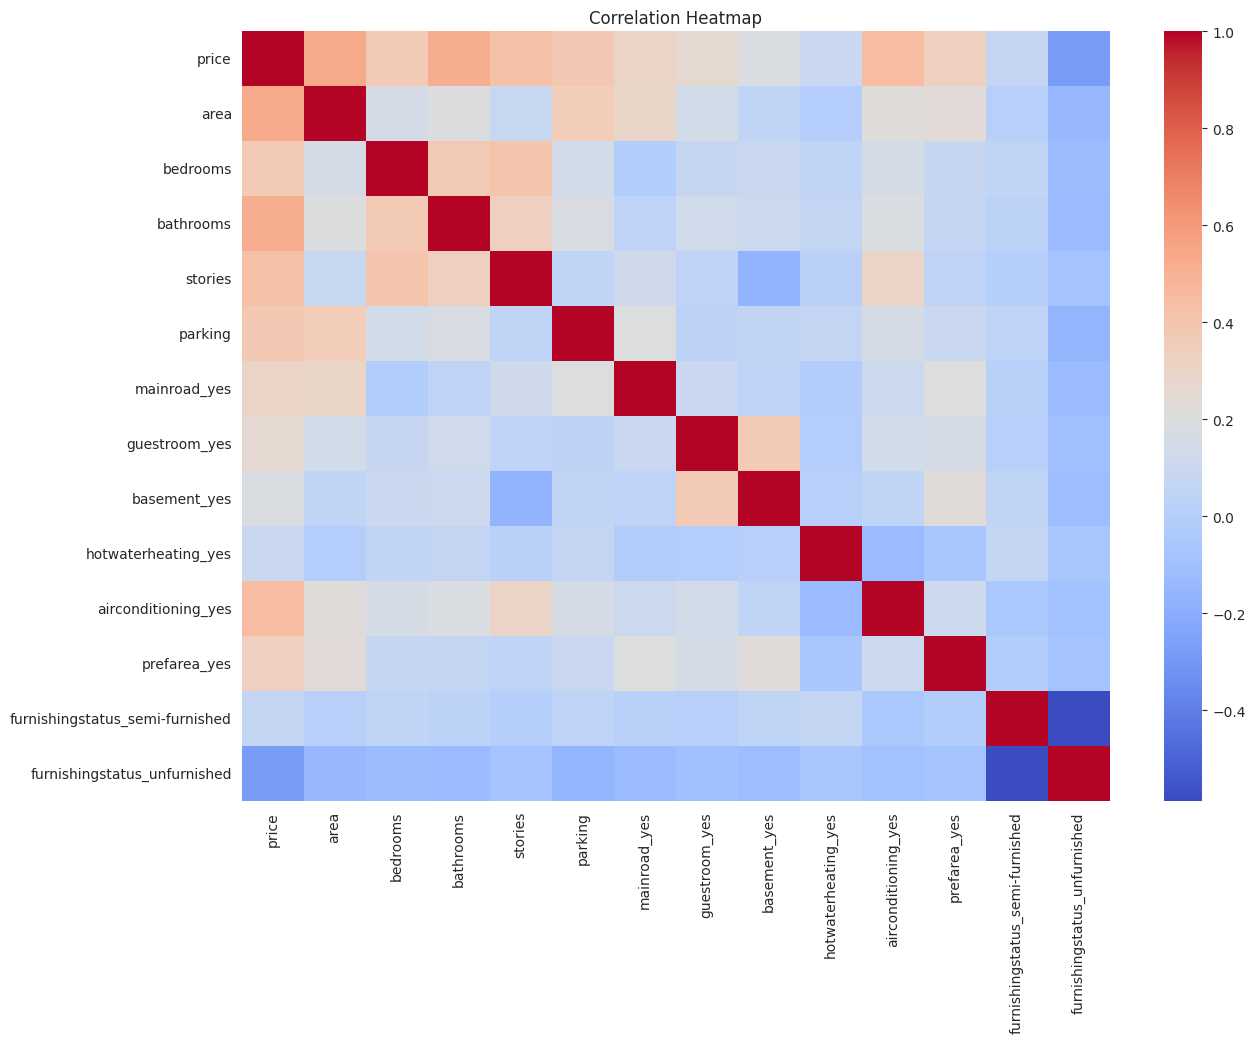

In [32]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_encoded.corr(),
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

 **Chart 3**: Actual vs Predicted Price

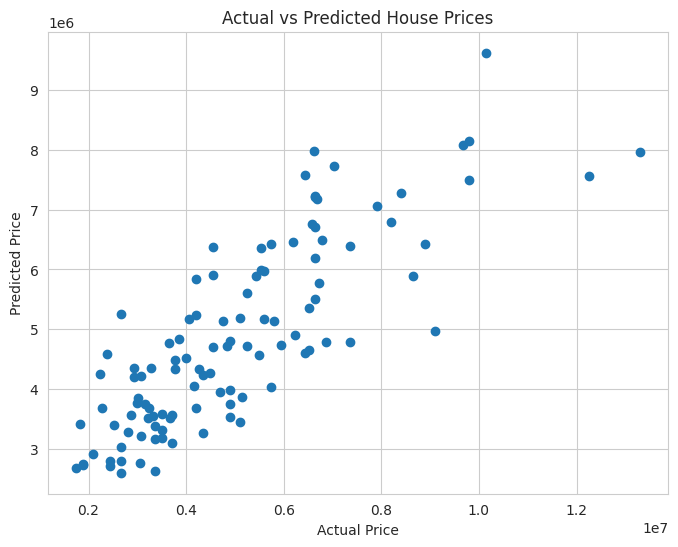

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("charts/actual_vs_predicted.png")

plt.show()

In [34]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

feature_importance[['Feature','Coefficient']].head(10)

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
12,furnishingstatus_unfurnished,-4.136451e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05


**Task 5** — Insights & Summary

## Insights & Summary
**Q. Which features influence house price the most?**

The housing price prediction project was completed using a dataset containing 545 house records with various features such as area, bedrooms, bathrooms, parking, furnishing status, and amenities. After preprocessing the data and converting categorical variables into numeric format, two machine learning models were trained: Linear Regression and Random Forest Regressor.

**Q. How accurate was your model (in plain terms)?**

The Linear Regression model performed better with an R² Score of approximately 0.65, meaning it was able to explain around 65% of the variation in house prices. The most influential features affecting house prices were bathrooms, air conditioning, hot water heating, preferred area, number of stories, and basement availability.

**Q. What surprised you in the data?**

One interesting observation was that amenities such as air conditioning and hot water heating had a significant impact on house prices, in addition to structural features like bathrooms and stories. Houses located in preferred areas also tended to have higher prices.

**Q. One recommendation for a real estate business based on your findings ?**

Based on these findings, real estate businesses should focus on highlighting premium amenities and location advantages when marketing properties, as these factors strongly influence customer purchasing decisions and property value.
